In [19]:
import numpy as np
from sklearn import datasets
from sklearn import model_selection
import matplotlib.pyplot as plt

In [20]:
def F_standardize(X):
    """
    standardize X, i.e. subtract mean (over data) and divide by standard-deviation (over data)

    Parameters
    ----------
    X: np.array of size (m, n_0)
        matrix containing the observation data

    Returns
    -------
    X: np.array of size (m, n_0)
        standardize version of X
    """

    X -= np.mean(X, axis=0, keepdims=True)
    X /= (np.std(X, axis=0, keepdims=True) + 1e-16)
    return X

In [21]:
def F_sigmoid(x):
    """Compute the value of the sigmoid activation function"""
    return 1 / (1 + np.exp(-x))

def F_relu(x):
    """Compute the value of the Rectified Linear Unit activation function"""
    return x * (x > 0)

def F_dRelu(x):
    """Compute the derivative of the Rectified Linear Unit activation function"""
    x[x<=0] = 0
    x[x>0] = 1
    return x

def F_computeCost(hat_y, y):
    """Compute the cost (mean of the losses)

    Parameters
    ----------
    hat_y: (m, 1)
        predicted value by the MLP
    y: (m, 1)
        ground-truth class to predict
    """
    m = y.shape[0]


# --- START CODE HERE (01)
    cost = - (1 / m) * np.sum(y * np.log(hat_y) + (1 - y) * np.log(1 - hat_y))

    # --- END CODE HERE

    return cost


def F_computeAccuracy(hat_y, y):
    """Compute the accuracy

    Parameters
    ----------
    hat_y: (m, 1)
        predicted value by the MLP
    y: (m, 1)
        ground-truth class to predict
    """

    m = y.shape[0]
    class_y = np.copy(hat_y)
    class_y[class_y>=0.5]=1
    class_y[class_y<0.5]=0
    return np.sum(class_y==y) / m

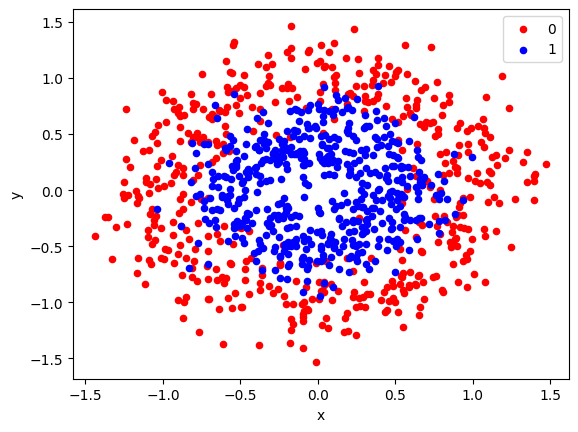

In [22]:
X, y = datasets.make_circles(n_samples=1000, noise=0.2, factor=0.5)

from pandas import DataFrame
# scatter plot, dots colored by class value
df = DataFrame(dict(x=X[:,0], y=X[:,1], label=y))
colors = {0:'red', 1:'blue'}
fig, ax = plt.subplots()
grouped = df.groupby('label')
for key, group in grouped:
    group.plot(ax=ax, kind='scatter', x='x', y='y', label=key, color=colors[key])
plt.show()

In [23]:
print("X.shape: {}".format(X.shape))
print("y.shape: {}".format(y.shape))
print(set(y))

# X is (m, n_0)
# y is (m,)

# --- Standardize data
X = F_standardize(X)

# --- Split between training set and test set
# --- (m, n_0)
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.2)

# --- Convert to proper shape: (m,) -> (m, 1)
y_train = y_train.reshape(len(y_train), 1)
y_test = y_test.reshape(len(y_test), 1)

# --- Convert to oneHotEncoding: (nbExamples, 1) -> (nbExamples, nbClass)
n_0 = X_train.shape[1]
n_2 = 1

print("X_train.shape: {}".format(X_train.shape))
print("X_test.shape: {}".format(X_test.shape))
print("y_train.shape: {}".format(y_train.shape))
print("y_test.shape: {}".format(y_test.shape))
print("y_train.shape: {}".format(y_train.shape))
print("y_test.shape: {}".format(y_test.shape))
print("n_0=n_in: {} n_2=n_out: {}".format(n_0, n_2))

X.shape: (1000, 2)
y.shape: (1000,)
{0, 1}
X_train.shape: (800, 2)
X_test.shape: (200, 2)
y_train.shape: (800, 1)
y_test.shape: (200, 1)
y_train.shape: (800, 1)
y_test.shape: (200, 1)
n_0=n_in: 2 n_2=n_out: 1


In [24]:
class C_MultiLayerPerceptron:
    """
    A class used to represent a Multi-Layer Perceptron with 1 hidden layers

    ...

    Attributes
    ----------
    W1, b1, W2, b2:
        weights and biases to be learnt
    Z1, A1, Z2, A2:
        values of the internal neurons to be used for backpropagation
    dW1, db1, dW2, db2, dZ1, dZ2:
        partial derivatives of the loss w.r.t. parameters
        example: dW1 = dLoss/dW1
    VdW1, Vdb1, VdW2, Vdb2:
        momentum terms
    do_bin0_multi1:
        set wether we solve a binary or a multi-class classification problem

    Methods
    -------
    forward_propagation

    backward_propagation

    update_parameters

    """

    W1, b1, W2, b2 = [], [], [], []
    A0, Z1, A1, Z2, A2 = [], [], [], [], []
    dW1, db1, dW2, db2 = [], [], [], []
    dZ1, dA1, dZ2 = [], [], []
    # --- for momentum
    VdW1, Vdb1, VdW2, Vdb2 = [], [], [], []

    def __init__(self, n_0, n_1, n_2):
        self.W1 = np.random.randn(n_0, n_1) * 0.01
        self.b1 = np.zeros(shape=(1, n_1))
        self.W2 = np.random.randn(n_1, n_2) * 0.01
        self.b2 = np.zeros(shape=(1, n_2))
        # --- for momentum
        self.VdW1 = np.zeros(shape=(n_0, n_1))
        self.Vdb1 = np.zeros(shape=(1, n_1))
        self.VdW2 = np.zeros(shape=(n_1, n_2))
        self.Vdb2 = np.zeros(shape=(1, n_2))
        return


    def __setattr__(self, attrName, val):
        if hasattr(self, attrName):
            self.__dict__[attrName] = val
        else:
            raise Exception("self.%s note part of the fields" % attrName)



    def M_forwardPropagation(self, X):
        """Forward propagation in the MLP

        Parameters
        ----------
        X: numpy array (m, n_1)
            observation data

        Return
        ------
        hat_y: numpy array (m, 1)
            predicted value by the MLP
        """

        self.A0 = X
        # --- START CODE HERE (02)

        self.Z1 = np.dot(self.A0, self.W1) + self.b1
        self.A1 = 1 / (1 + np.exp(-self.Z1))  # sigmoid (couche cachée)

        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = 1 / (1 + np.exp(-self.Z2))  # sigmoid (sortie)

        hat_y = self.A2

        # --- END CODE HERE

        return hat_y


    def M_backwardPropagation(self, X, y):
        self.cache = {"Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}
        """Backward propagation in the MLP

        Parameters
        ----------
        X: numpy array (m, n_0)
            observation data
        y: numpy array (m, 1)
            ground-truth class to predict

        """

        m = y.shape[0]


        # --- START CODE HERE (03)

        # Erreur couche sortie
        dZ2 = self.A2 - y
        self.dW2 = (1 / m) * np.dot(self.A1.T, dZ2)
        self.db2 = (1 / m) * np.sum(dZ2, axis=0, keepdims=True)

        # Erreur couche cachée
        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * self.A1 * (1 - self.A1)  # dérivée sigmoid

        self.dW1 = (1 / m) * np.dot(self.A0.T, dZ1)
        self.db1 = (1 / m) * np.sum(dZ1, axis=0, keepdims=True)

        # --- END CODE HERE


        return


    def M_gradientDescent(self, alpha):
        """Update the parameters of the network using gradient descent

        Parameters
        ----------
        alpha: float scalar
            amount of update at each step of the gradient descent

        """

        # --- START CODE HERE (04)
        self.W1 = self.W1 - alpha * self.dW1
        self.b1 = self.b1 - alpha * self.db1

        self.W2 = self.W2 - alpha * self.dW2
        self.b2 = self.b2 - alpha * self.db2

        # --- END CODE HERE

        return


    def M_momentum(self, alpha, beta):
        """Update the parameters of the network using momentum method

        Parameters
        ----------
        alpha: float scalar
            amount of update at each step of the gradient descent
        beta: float scalar
            momentum term
        """

       # --- START CODE HERE (05)
         # Vitesse couche 1
        self.vdW1 = beta * getattr(self, 'vdW1', 0) + (1 - beta) * self.dW1
        self.vdb1 = beta * getattr(self, 'vdb1', 0) + (1 - beta) * self.db1

        # Vitesse couche 2
        self.vdW2 = beta * getattr(self, 'vdW2', 0) + (1 - beta) * self.dW2
        self.vdb2 = beta * getattr(self, 'vdb2', 0) + (1 - beta) * self.db2

        # Mise à jour des paramètres
        self.W1 = self.W1 - alpha * self.vdW1
        self.b1 = self.b1 - alpha * self.vdb1

        self.W2 = self.W2 - alpha * self.vdW2
        self.b2 = self.b2 - alpha * self.vdb2

        # --- END CODE HERE
        return

In [25]:
# hyper-parameters
n_1 = 10 # number of hidden neurons
nb_epoch = 5000 #5000 # number of epochs (number of iterations over full training set)
alpha=0.1 # learning rate
beta=0.9 # beat parameters for momentum


# Instantiate the class MLP with providing
# the size of the various layers (n_0=n_input, n_1=n_hidden, n_2=n_output)
myMLP = C_MultiLayerPerceptron(n_0, n_1, n_2)

train_cost, train_accuracy, test_cost, test_accuracy = [], [], [], []

# Run over epochs
for num_epoch in range(0, nb_epoch):

    # --- Forward
    hat_y_train = myMLP.M_forwardPropagation(X_train)

    # --- Store results on train
    train_cost.append( F_computeCost(hat_y_train, y_train) )
    train_accuracy.append( F_computeAccuracy(hat_y_train, y_train) )

    # --- Backward
    myMLP.M_backwardPropagation(X_train, y_train)

    # --- Update
    myMLP.M_gradientDescent(alpha)
    #myMLP.M_momentum(alpha, beta)

    # --- Store results on test
    hat_y_test = myMLP.M_forwardPropagation(X_test)
    test_cost.append( F_computeCost(hat_y_test, y_test) )
    test_accuracy.append( F_computeAccuracy(hat_y_test, y_test) )

    if (num_epoch % 500)==0:
        print("epoch: {0:d} (cost: train {1:.2f} test {2:.2f}) (accuracy: train {3:.2f} test {4:.2f})".format(num_epoch, train_cost[-1], test_cost[-1], train_accuracy[-1], test_accuracy[-1]))

NameError: name 'Z1' is not defined

In [ ]:
plt.subplot(1,2,1)
plt.plot(train_cost, 'r')
plt.plot(test_cost, 'g--')
plt.xlabel('# epoch')
plt.ylabel('loss')
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(train_accuracy, 'r')
plt.plot(test_accuracy, 'g--')
plt.xlabel('# epoch')
plt.ylabel('accuracy')
plt.grid(True)

In [ ]:
! pip install pretty_midi
import os
import pretty_midi
from scipy.io import wavfile
import IPython

from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, LSTM, Flatten, Dropout, Activation

import matplotlib.pyplot as plt
import numpy as np
import glob

In [ ]:
n_x = 79
max_T_x = 1000
sequence_length = 20
T_y_generated = 200

In [ ]:
DIR = './'
import urllib.request
midiFile_l = ['cs1-2all.mid', 'cs5-1pre.mid', 'cs4-1pre.mid', 'cs3-5bou.mid', 'cs1-4sar.mid', 'cs2-5men.mid', 'cs3-3cou.mid', 'cs2-3cou.mid', 'cs1-6gig.mid', 'cs6-4sar.mid', 'cs4-5bou.mid', 'cs4-3cou.mid', 'cs5-3cou.mid', 'cs6-5gav.mid', 'cs6-6gig.mid', 'cs6-2all.mid', 'cs2-1pre.mid', 'cs3-1pre.mid', 'cs3-6gig.mid', 'cs2-6gig.mid', 'cs2-4sar.mid', 'cs3-4sar.mid', 'cs1-5men.mid', 'cs1-3cou.mid', 'cs6-1pre.mid', 'cs2-2all.mid', 'cs3-2all.mid', 'cs1-1pre.mid', 'cs5-2all.mid', 'cs4-2all.mid', 'cs5-5gav.mid', 'cs4-6gig.mid', 'cs5-6gig.mid', 'cs5-4sar.mid', 'cs4-4sar.mid', 'cs6-3cou.mid']
for midiFile in midiFile_l:
  #if os.path.isfile(DIR + midiFile) is None:
  urllib.request.urlretrieve ("http://www.jsbach.net/midi/" + midiFile, DIR + midiFile)
nbExample = len(midiFile_l)

midiFile_l = glob.glob(DIR + 'cs*.mid')
print(midiFile_l)

In [ ]:
# --- Read a single MIDI file
midi_data = pretty_midi.PrettyMIDI(midiFile_l[0])
# --- Display the note pitch, start, end and duration
for note in midi_data.instruments[0].notes:
    print('pitch: %d, start: %f, end: %f, duration: %f' % (note.pitch, note.start, note.end, note.end-note.start))

In [ ]:
# --- We truncate the duration of each example to the first T_x data

X_list = []

for midiFile in midiFile_l:
    # read the MIDI file
    midi_data = pretty_midi.PrettyMIDI(midiFile)
    note_l = [note.pitch for note in midi_data.instruments[0].notes]
    # convert to one-hot-encoding
    T_x = len(note_l)
    if T_x > max_T_x:
      T_x = max_T_x
    X_ohe = np.zeros((T_x, n_x))
    for t in range(T_x):
      X_ohe[t, note_l[t]-1] = 1
    # add to the list
    X_list.append(X_ohe)

print(len(X_list))
print(X_list[0].shape)
print(X_list[1].shape)
print(X_list[2].shape)

In [ ]:
plt.figure(figsize=(16, 6))
plt.imshow(X_list[2].T, aspect='auto')
plt.set_cmap('gray_r')
plt.grid(True)

In [ ]:
X_train_list = []
y_train_list = []

# --- START CODE HERE (06)

X_train_list.extend([row for row in X])                   # (n0,)
y_train_list.extend([row for row in y.reshape(-1, 1)])    # (1,)

# --- END CODE HERE

X_train = np.asarray(X_train_list)
y_train = np.asarray(y_train_list)

print("X_train.shape:", X_train.shape)
print("y_train.shape:", y_train.shape)

In [ ]:
# --- Create the model
K.clear_session()

# --- START CODE HERE (07)

# --- END CODE HERE

print(model.summary())

In [ ]:
# --- Compile and fit the model
model.compile(loss='categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=10, batch_size=64)

In [ ]:
# --- Select a random starting pattern
start = np.random.randint(0, len(X_train_list)-1)
pattern = X_train_list[start]
print(start)
print(pattern.shape)
print(np.expand_dims(pattern, 0).shape)

In [ ]:
from tensorflow.keras.utils import to_categorical

# --- note_l: is the list of notes (integer number) over time
note_l = []
# ---note: is the list of notes (one hot encoding) over time
note = []
#on initialise note avec les notes dans le pattern initial
for i in range(0, sequence_length):
  note.append(pattern[i])

# --- prediction_l: is the list of output-vectors (float numbers \in [0,1]) of the network over time
prediction_l = []
# --- Generate T_y_generated notes
for note_index in range(T_y_generated):

    # --- START CODE HERE (08)

    # --- END CODE HERE

In [ ]:
print(note_l)

plt.figure(figsize=(16, 6))
plt.imshow(np.asarray(prediction_l)[:,0,:].T, aspect='auto', origin='lower')
plt.show()
plt.plot(note_l)
plt.set_cmap('gray_r')
plt.grid(True)

In [ ]:
new_midi_data = pretty_midi.PrettyMIDI()
cello_program = pretty_midi.instrument_name_to_program('Cello')
cello = pretty_midi.Instrument(program=cello_program)
time = 0
step = 0.3
for note_number in note_l:
    myNote = pretty_midi.Note(velocity=100, pitch=note_number, start=time, end=time+step)
    cello.notes.append(myNote)
    time += step
new_midi_data.instruments.append(cello)
new_midi_data.write('output.mid')

In [ ]:
%matplotlib inline

audio_data = new_midi_data.synthesize()
IPython.display.Audio(audio_data, rate=44100)